### `Task` Train a KNN model on glass type dataset and find best n_neighnours.

Data Link: https://drive.google.com/file/d/17cbDNBmys04MJqQfrma3jd72VPMnxIq0/view?usp=share_link

In [2]:
import numpy as np
import pandas as pd

In [3]:
data=pd.read_csv("glass.csv")

In [4]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
data.shape

(214, 10)

In [6]:
data.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [7]:
data.value_counts()

RI       Na     Mg    Al    Si     K     Ca     Ba    Fe    Type
1.52213  14.21  3.82  0.47  71.77  0.11  9.57   0.00  0.00  1       2
1.51131  13.69  3.20  1.81  72.81  1.76  5.43   1.19  0.00  7       1
1.51215  12.99  3.47  1.12  72.98  0.62  8.35   0.00  0.31  1       1
1.51299  14.40  1.74  1.54  74.55  0.00  7.59   0.00  0.00  6       1
1.51115  17.38  0.00  0.34  75.41  0.00  6.65   0.00  0.00  6       1
                                                                   ..
1.52725  13.80  3.15  0.66  70.57  0.08  11.64  0.00  0.00  2       1
1.52739  11.02  0.00  0.75  73.08  0.00  14.96  0.00  0.00  2       1
1.52777  12.64  0.00  0.67  72.02  0.06  14.40  0.00  0.00  2       1
1.53125  10.73  0.00  2.10  69.81  0.58  13.30  3.15  0.28  2       1
1.53393  12.30  0.00  1.00  70.16  0.12  16.19  0.00  0.24  2       1
Name: count, Length: 213, dtype: int64

In [8]:
X=data.drop("Type",axis=1)
y=data["Type"]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [11]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [12]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred)*100,2),"%")

Accuracy Score: 65.12 %


#Testing wih multiple k vales to find the most optimal value

In [13]:
# 1,16
scores=[]
for i in range(1,16):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred=knn.predict(X_test)
  print("Accuracy Score for k=",i,":",round(accuracy_score(y_test,y_pred)*100,2),"%")
  scores.append(accuracy_score(y_test,y_pred))

Accuracy Score for k= 1 : 83.72 %
Accuracy Score for k= 2 : 76.74 %
Accuracy Score for k= 3 : 74.42 %
Accuracy Score for k= 4 : 69.77 %
Accuracy Score for k= 5 : 65.12 %
Accuracy Score for k= 6 : 60.47 %
Accuracy Score for k= 7 : 60.47 %
Accuracy Score for k= 8 : 65.12 %
Accuracy Score for k= 9 : 62.79 %
Accuracy Score for k= 10 : 62.79 %
Accuracy Score for k= 11 : 62.79 %
Accuracy Score for k= 12 : 62.79 %
Accuracy Score for k= 13 : 62.79 %
Accuracy Score for k= 14 : 65.12 %
Accuracy Score for k= 15 : 65.12 %


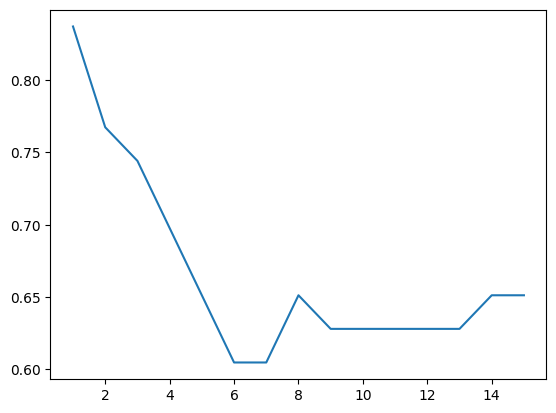

In [14]:
import matplotlib.pyplot as plt
plt.plot(range(1,16),scores)

The best value for k is 1 (but is it overfitting ?)

Includeing grid search cv

In [16]:
from sklearn.model_selection import GridSearchCV
param_grid={"n_neighbors":range(1,16)}
knnc=GridSearchCV(KNeighborsClassifier(),param_grid)

In [17]:
knnc.fit(X_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(1, 16)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,8


In [18]:
knnc.best_params_

{'n_neighbors': 8}